# Modelling

## Load Data

In [5]:
import pandas as pd
import numpy as np

# 1. Load data hasil PCA dari file CSV
df_pca = pd.read_csv('detik_pca_results.csv')

# 2. Tampilkan 5 baris pertama data
print("=== 5 BARIS PERTAMA DATA PCA ===")
display(df_pca.head())

=== 5 BARIS PERTAMA DATA PCA ===


,id,label,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,...,PC118,PC119,PC120,PC121,PC122,PC123,PC124,PC125,PC126,PC127
0,1,1,-0.053773,-0.061885,-0.000350,-0.058837,0.013994,0.068289,-0.053779,-0.017443,...,0.023696,-0.014662,0.002958,-0.056835,-0.000180,0.010376,-0.022925,0.033728,0.001292,0.005652
1,2,1,-0.075346,-0.148679,-0.016338,0.051595,-0.020576,0.134382,-0.033391,-0.026942,...,0.056043,0.041373,0.076120,-0.027974,-0.031815,-0.066777,-0.020641,-0.094571,-0.030472,-0.017983
2,3,1,-0.050023,-0.170970,0.001593,0.063843,-0.022446,0.094287,-0.009641,0.008280,...,0.127183,-0.003806,-0.025368,-0.079310,0.118688,-0.030169,-0.084056,0.033637,-0.035244,0.024356
3,4,1,-0.065748,-0.217047,-0.014092,0.162086,-0.060429,0.088339,-0.013755,-0.004416,...,0.044703,0.017393,0.122329,-0.009212,0.044905,0.053537,-0.079858,0.009061,-0.074851,0.043998
4,5,1,0.459457,0.061303,0.001194,0.031441,0.042039,-0.046271,0.009134,0.134920,...,-0.062945,-0.046471,0.013460,0.009175,0.031476,0.213290,-0.037325,-0.040529,-0.013520,-0.071726


In [6]:
# 1. Pisahkan Fitur (X) dan Target (y)
X = df_pca.drop(columns=['id', 'label'])
y = df_pca['label']

print(f"• Jumlah Sampel Data (Baris) : {X.shape[0]}")
print(f"• Jumlah Fitur PCA (Kolom)   : {X.shape[1]}")

• Jumlah Sampel Data (Baris) : 200
• Jumlah Fitur PCA (Kolom)   : 127


## Spliting data 80/20

In [7]:
from sklearn.model_selection import train_test_split

# Pembagian data (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("=== HASIL PEMBAGIAN DATA ===")
print(f"• Data Training (80%) : {X_train.shape[0]} sampel")
print(f"• Data Testing  (20%) : {X_test.shape[0]} sampel")

=== HASIL PEMBAGIAN DATA ===
• Data Training (80%) : 160 sampel
• Data Testing  (20%) : 40 sampel


## Modelling

### Inisialisasi Model Klasifikasi

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc

# 1. Load Data Hasil PCA
df_pca = pd.read_csv('detik_pca_results.csv')
X = df_pca.drop(columns=['id', 'label'])
y = df_pca['label']

# 2. Split Data 80% Training dan 20% Testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Tempat menyimpan ringkasan evaluasi akhir
eval_summary = []
roc_data = {}

# Fungsi untuk evaluasi metrik & plotting Confusion Matrix tiap model
def evaluate_model(model_name, y_true, y_pred, y_prob=None):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    
    print(f"==========================================")
    print(f"   HASIL EVALUASI MODEL: {model_name.upper()}")
    print(f"==========================================")
    print(f"• Accuracy  : {acc*100:.2f}%")
    print(f"• Precision : {prec*100:.2f}%")
    print(f"• Recall    : {rec*100:.2f}%")
    print(f"• F1-Score  : {f1*100:.2f}%\n")
    
    # Plot Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Finance (0)', 'Sport (1)'],
                yticklabels=['Finance (0)', 'Sport (1)'],
                annot_kws={"size": 13, "weight": "bold"})
    plt.title(f'Confusion Matrix - {model_name}', fontsize=12, fontweight='bold')
    plt.xlabel('Prediksi Model')
    plt.ylabel('Label Sebenarnya')
    plt.tight_layout()
    plt.show()
    
    # Simpan hasil untuk perbandingan akhir
    eval_summary.append({
        'Model': model_name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1
    })
    
    if y_prob is not None:
        roc_data[model_name] = y_prob

print(".... Selesai persiapan data dan pembuatan fungsi\n")

....Selesai persiapan data dan pembuatan fungsi



### Naive Bayes

Memulai pelatihan Naive Bayes...
   HASIL EVALUASI MODEL: NAIVE BAYES
• Accuracy  : 85.00%
• Precision : 85.35%
• Recall    : 85.00%
• F1-Score  : 84.96%



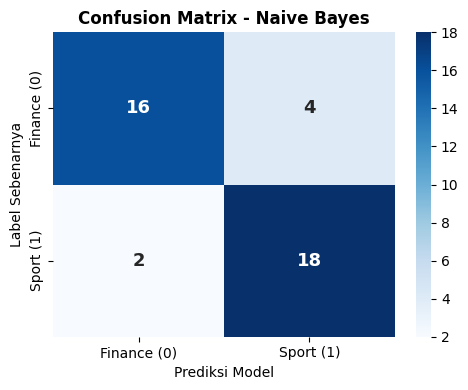

Selesai proses Naive Bayes...



In [21]:
from sklearn.naive_bayes import GaussianNB

print("Memulai pelatihan Naive Bayes...")
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)
y_prob_nb = nb_model.predict_proba(X_test)[:, 1]

# Evaluasi & Confusion Matrix
evaluate_model('Naive Bayes', y_test, y_pred_nb, y_prob_nb)

print("Selesai proses Naive Bayes...\n")

### Support Vector Machine(SVM)

Memulai pelatihan SVM...
   HASIL EVALUASI MODEL: SVM
• Accuracy  : 95.00%
• Precision : 95.00%
• Recall    : 95.00%
• F1-Score  : 95.00%



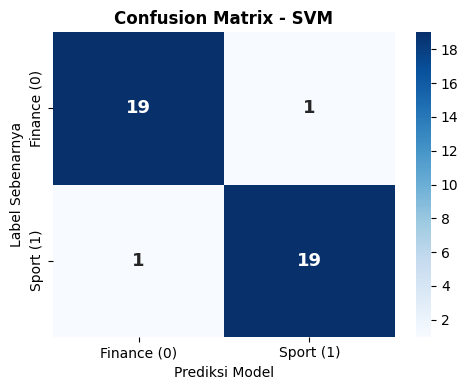

Selesai proses SVM...



In [22]:
from sklearn.svm import SVC

print("Memulai pelatihan SVM...")
svm_model = SVC(kernel='rbf', C=1.0, probability=True, random_state=42)
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)
y_prob_svm = svm_model.predict_proba(X_test)[:, 1]

# Evaluasi & Confusion Matrix
evaluate_model('SVM', y_test, y_pred_svm, y_prob_svm)

print("Selesai proses SVM...\n")

### K-Nearest Neighbors(KNN)

Memulai pelatihan KNN...
   HASIL EVALUASI MODEL: KNN
• Accuracy  : 97.50%
• Precision : 97.62%
• Recall    : 97.50%
• F1-Score  : 97.50%



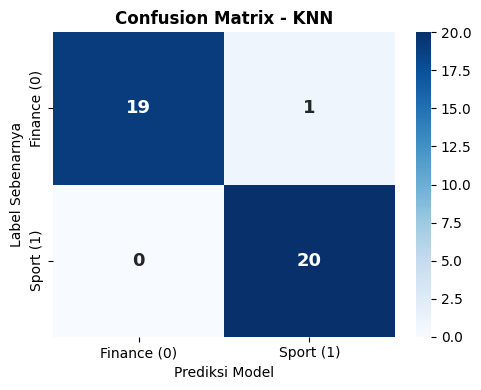

Selesai proses KNN...



In [23]:
from sklearn.neighbors import KNeighborsClassifier

print("Memulai pelatihan KNN...")
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)
y_prob_knn = knn_model.predict_proba(X_test)[:, 1]

# Evaluasi & Confusion Matrix
evaluate_model('KNN', y_test, y_pred_knn, y_prob_knn)

print("Selesai proses KNN...\n")

### Random Forest

Memulai pelatihan Random Forest...
   HASIL EVALUASI MODEL: RANDOM FOREST
• Accuracy  : 90.00%
• Precision : 90.00%
• Recall    : 90.00%
• F1-Score  : 90.00%



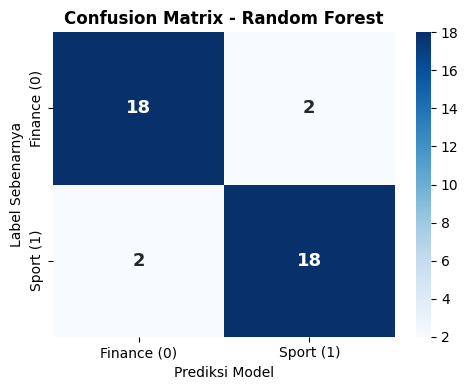

Selesai proses Random Forest...



In [24]:
from sklearn.ensemble import RandomForestClassifier

print("Memulai pelatihan Random Forest...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# Evaluasi & Confusion Matrix
evaluate_model('Random Forest', y_test, y_pred_rf, y_prob_rf)

print("Selesai proses Random Forest...\n")

### Logistic Regression

Memulai pelatihan Logistic Regression...
   HASIL EVALUASI MODEL: LOGISTIC REGRESSION
• Accuracy  : 97.50%
• Precision : 97.62%
• Recall    : 97.50%
• F1-Score  : 97.50%



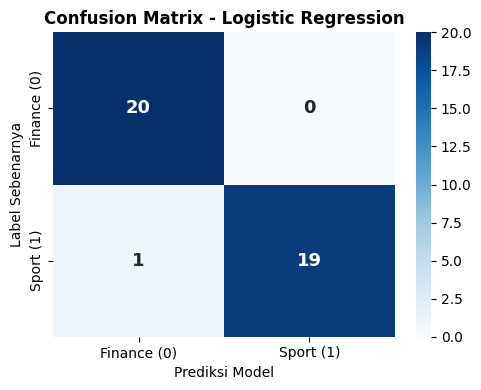

Selesai proses Logistic Regression...



In [25]:
from sklearn.linear_model import LogisticRegression

print("Memulai pelatihan Logistic Regression...")
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)
y_prob_lr = lr_model.predict_proba(X_test)[:, 1]

# Evaluasi & Confusion Matrix
evaluate_model('Logistic Regression', y_test, y_pred_lr, y_prob_lr)

print("Selesai proses Logistic Regression...\n")

### Evaluasi Akhir & Perbandingan Gabungan

Memulai pembuatan evaluasi akhir dan grafik perbandingan...
=== TABEL PERBANDINGAN SELURUH MODEL ===


,Model,Accuracy,Precision,Recall,F1-Score
0,Naive Bayes,85.00%,85.35%,85.00%,84.96%
1,SVM,95.00%,95.00%,95.00%,95.00%
2,KNN,97.50%,97.62%,97.50%,97.50%
3,Random Forest,90.00%,90.00%,90.00%,90.00%
4,Logistic Regression,97.50%,97.62%,97.50%,97.50%


Selesai menampilkan tabel perbandingan...



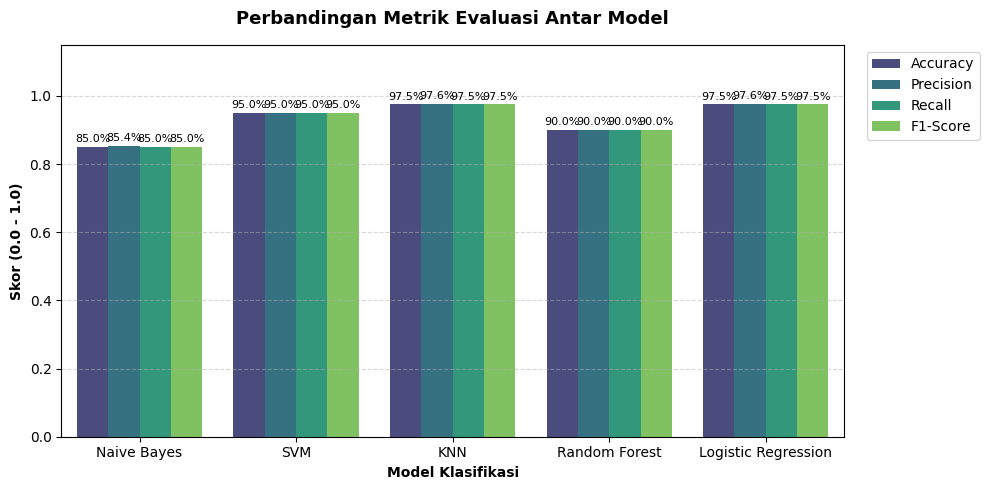

Selesai menampilkan bar chart perbandingan...



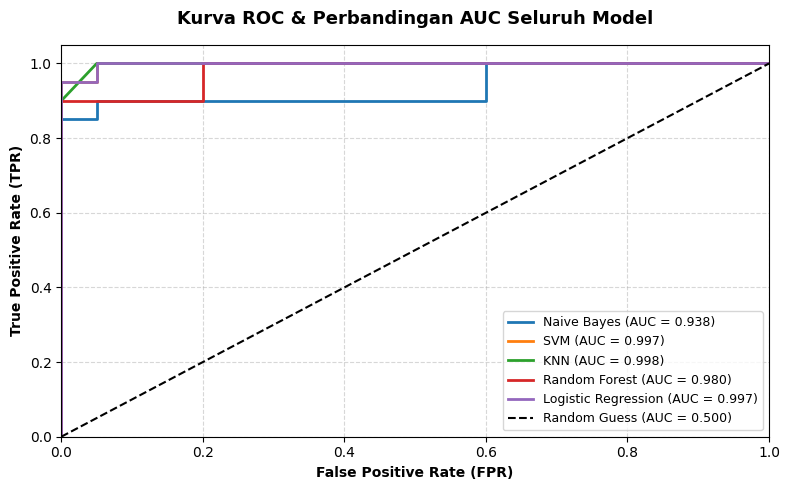

Selesai menampilkan kurva ROC-AUC...

Selesai seluruh rangkaian pemodelan dan evaluasi!


In [26]:
print("Memulai pembuatan evaluasi akhir dan grafik perbandingan...")

# 1. Tabel Perbandingan Metrik
df_summary = pd.DataFrame(eval_summary)
df_display = df_summary.copy()
for col in ['Accuracy', 'Precision', 'Recall', 'F1-Score']:
    df_display[col] = df_display[col].map(lambda x: f"{x*100:.2f}%")

print("=== TABEL PERBANDINGAN SELURUH MODEL ===")
display(df_display)
print("Selesai menampilkan tabel perbandingan...\n")

# 2. Bar Chart Perbandingan Metrik
df_melted = pd.melt(df_summary, id_vars=['Model'], var_name='Metric', value_name='Score')

plt.figure(figsize=(10, 5))
ax = sns.barplot(x='Model', y='Score', hue='Metric', data=df_melted, palette='viridis')

plt.title('Perbandingan Metrik Evaluasi Antar Model', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Model Klasifikasi', fontweight='bold')
plt.ylabel('Skor (0.0 - 1.0)', fontweight='bold')
plt.ylim(0, 1.15)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.5)

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{height*100:.1f}%',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=8, xytext=(0, 2),
                    textcoords='offset points')

plt.tight_layout()
plt.show()
print("Selesai menampilkan bar chart perbandingan...\n")

# 3. Perbandingan Kurva ROC & AUC
plt.figure(figsize=(8, 5))

for model_name, y_prob in roc_data.items():
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{model_name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Guess (AUC = 0.500)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)', fontweight='bold')
plt.ylabel('True Positive Rate (TPR)', fontweight='bold')
plt.title('Kurva ROC & Perbandingan AUC Seluruh Model', fontsize=13, fontweight='bold', pad=15)
plt.legend(loc="lower right", fontsize=9)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
print("Selesai menampilkan kurva ROC-AUC...\n")

print("Selesai seluruh rangkaian pemodelan dan evaluasi!")

Hasil evaluasi menunjukkan bahwa lima algoritma klasifikasi yang diuji memiliki performa yang sangat baik secara keseluruhan. Model KNN dan Logistic Regression menjadi pilihan paling optimal karena mencatatkan kinerja tertinggi dengan akurasi, Precision, Recall, serta F1-Score mencapai 97,5%, didukung oleh nilai AUC yang mendekati sempurna yaitu 0,998 dan 0,997. Di posisi berikutnya, SVM tampil stabil dengan skor 95,0% (AUC 0,997), diikuti oleh Random Forest sebesar 90,0% (AUC 0,980), sementara Naive Bayes mencatatkan skor terendah dengan akurasi 85,0% dan nilai AUC 0,938.